# Non-Hermitian Hamiltonians
An open system that exchanges particles or energy with its environment is described by an
effective Hamiltonian that is no longer Hermitian: gain and loss enter as imaginary onsite
energies, and a non-reciprocal hopping, with $t_{ij}\ne t_{ji}^*$, as an asymmetric hopping
matrix. The eigenvalues are then complex, and their imaginary part is an amplification or a
decay rate rather than an energy. pyqula builds such a Hamiltonian with
`g.get_hamiltonian(non_hermitian=True)`, after which the band structure, the density of
states, the LDOS and the Berry curvature are computed with their non-Hermitian versions. We
will go through a chain with gain and loss, a chain with non-reciprocal hopping, a lossy
supercell and a Chern insulator with gain and loss.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Gain and loss in a chain
Let us take a chain of thirty sites with a purely imaginary onsite energy, gain where the
cosine is positive and loss where it is negative. The eigenvalues spread over the complex
plane, and `h.get_ldos(eigmode="imag")` selects the states by their imaginary part instead of
by their energy, so that the map on the right shows where the states with each gain or decay
rate live. The most amplified states sit where the gain is largest, the most damped ones
where the loss is, and the states with a real eigenvalue at the two points where the onsite
energy changes sign.

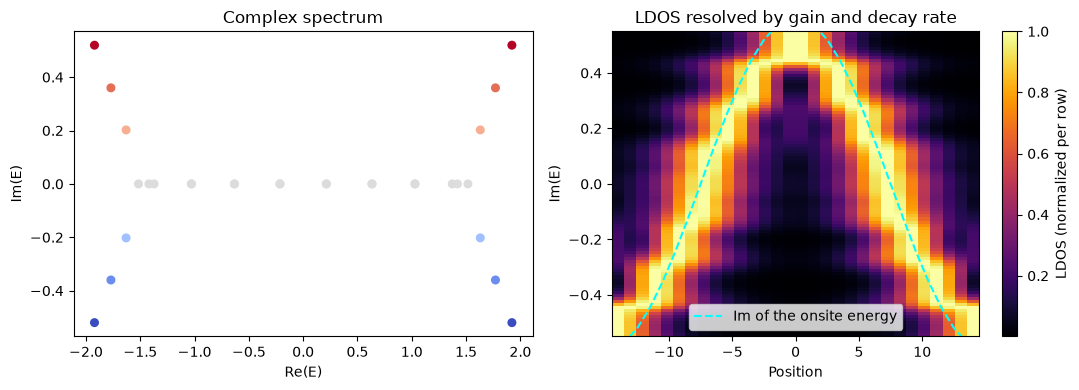

In [2]:
n = 30
g = geometry.chain().get_supercell(n) # supercell of a chain
h = g.get_hamiltonian(has_spin=False,non_hermitian=True,tij=[-1.]) # non-Hermitian Hamiltonian
h.add_onsite(lambda r: 0.6j*np.cos(2.*np.pi*r[0]/n)) # gain and loss

(ks,es) = h.get_bands(kpath=[[0.,0.,0.]],write=False) # complex eigenvalues at k=0

rates = np.linspace(-0.55,0.55,100) # imaginary part of the eigenvalue
ldos = []
for w in rates:
    (x,y,d) = h.get_ldos(e=w,delta=2e-2,eigmode="imag",nrep=1) # states selected by Im(E)
    ldos.append(d/np.max(d)) # normalize each row
ldos = np.array(ldos)
order = np.argsort(x) # sort the sites by position

fig,axs = plt.subplots(1,2,figsize=(11,4))
axs[0].scatter(es.real,es.imag,c=es.imag,cmap="coolwarm",s=30)
axs[0].set_xlabel("Re(E)") ; axs[0].set_ylabel("Im(E)")
axs[0].set_title("Complex spectrum")
im = axs[1].imshow(ldos[:,order],origin="lower",aspect="auto",cmap="inferno",
        extent=[x.min(),x.max(),rates[0],rates[-1]])
axs[1].plot(x[order],0.6*np.cos(2.*np.pi*x[order]/n),c="cyan",ls="--",label="Im of the onsite energy")
axs[1].set_ylim([rates[0],rates[-1]])
axs[1].set_xlabel("Position") ; axs[1].set_ylabel("Im(E)")
axs[1].set_title("LDOS resolved by gain and decay rate")
axs[1].legend(loc="lower center")
plt.colorbar(im,ax=axs[1],label="LDOS (normalized per row)")
plt.tight_layout()
plt.show()

### Non-reciprocal hopping and the skin effect
A non-reciprocal hopping is passed as a hopping function `tij(r1,r2)` that is not symmetric
in its two arguments. Here the hopping to the right and to the left differ by $2\gamma$, the
Hatano-Nelson chain, in a finite chain of thirty sites. For $\gamma=0$ the LDOS as a function
of position and energy shows the standing waves of a finite chain, spread over the whole
system. For $\gamma\neq 0$ every eigenstate piles up at one end of the chain, which is what
is called the non-Hermitian skin effect.

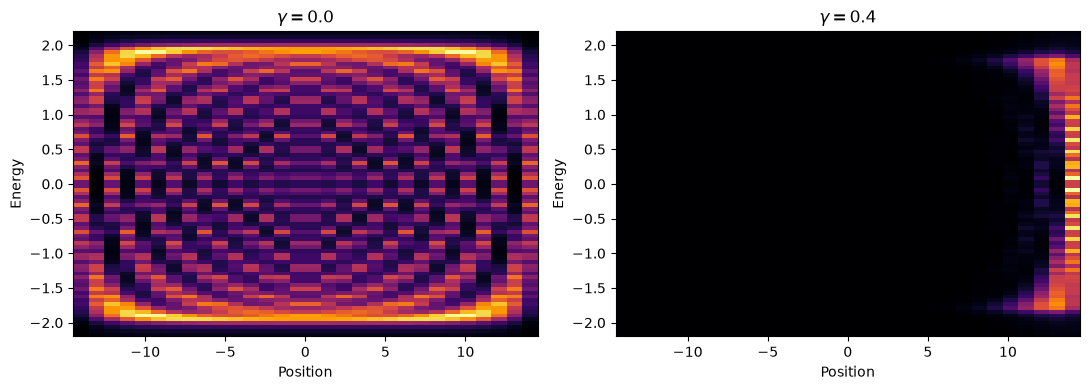

In [3]:
n = 30
g = geometry.chain().get_supercell(n) # thirty sites
g.dimensionality = 0 # finite chain, open boundaries

energies = np.linspace(-2.2,2.2,80)
fig,axs = plt.subplots(1,2,figsize=(11,4))
for (ax,gamma) in zip(axs,[0.,0.4]):
    def tij(r1,r2): # hopping from r2 to r1, different to the right and to the left
        dx = r1[0]-r2[0]
        if abs(abs(dx)-1.)<1e-3: return -1. - gamma*np.sign(dx)
        return 0.
    h = g.get_hamiltonian(has_spin=False,non_hermitian=True,tij=tij)
    ldos = []
    for e in energies:
        (x,y,d) = h.get_ldos(e=e,delta=5e-2,nrep=1) # LDOS at this energy
        ldos.append(d)
    ldos = np.array(ldos)
    order = np.argsort(x)
    ax.imshow(ldos[:,order],origin="lower",aspect="auto",cmap="inferno",
            extent=[x.min(),x.max(),energies[0],energies[-1]])
    ax.set_xlabel("Position") ; ax.set_ylabel("Energy")
    ax.set_title(r"$\gamma=$"+str(gamma))
plt.tight_layout()
plt.show()

### The two spectral functions of a lossy supercell
A non-Hermitian Hamiltonian has right and left eigenvectors that are different, and so two
momentum-resolved spectral functions. `h.get_kdos_bands()` weighs each state with its right
eigenvector by default, and with `biorthogonal=True` it returns the Green's-function spectral
function, where a state with $\mathrm{Im}(E)<0$ is broadened by its lifetime. Here a chain in
a supercell of four sites, with a modulated loss, is unfolded onto the Brillouin zone of the
chain: the default gives sharp bands with small gaps at the folding points, while the
Green's-function one shows each band broadened by the loss of the states it is made of.

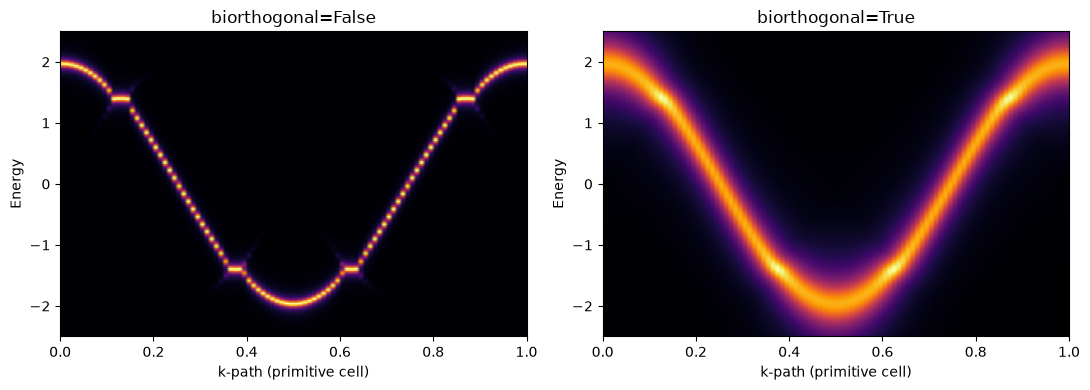

In [4]:
g = geometry.chain().get_supercell(4,store_primal=True) # supercell of a chain
h = g.get_hamiltonian(has_spin=False,non_hermitian=True) # non-Hermitian Hamiltonian
h.add_onsite(lambda r: -0.3j*(1.+np.cos(np.pi*r[0]/2.))) # modulated loss
kpath = g.get_unfolded_kpath(nk=100) # primitive k-path, in supercell coordinates
energies = np.linspace(-2.5,2.5,200)

fig,axs = plt.subplots(1,2,figsize=(11,4))
for (ax,bi) in zip(axs,[False,True]):
    (k,e,d) = h.get_kdos_bands(operator="unfold",kpath=kpath,energies=energies,
            delta=5e-2,biorthogonal=bi) # unfolded spectral function
    d = d.reshape(len(kpath),len(energies)) # one row per k-point
    ax.imshow(d.T,origin="lower",aspect="auto",cmap="inferno",
            extent=[0.,1.,energies[0],energies[-1]])
    ax.set_xlabel("k-path (primitive cell)") ; ax.set_ylabel("Energy")
    ax.set_title("biorthogonal="+str(bi))
plt.tight_layout()
plt.show()

### Berry curvature of a Chern insulator with gain and loss
Finally, the Berry curvature. We take the Haldane model, a Chern insulator, and add gain on
one sublattice and loss on the other. `h.get_berry_curvature()` computes it from the Green's
function for a non-Hermitian Hamiltonian, and the map over the Brillouin zone shows it
concentrated around the K and K' points, where the gap of the Haldane model is smallest.

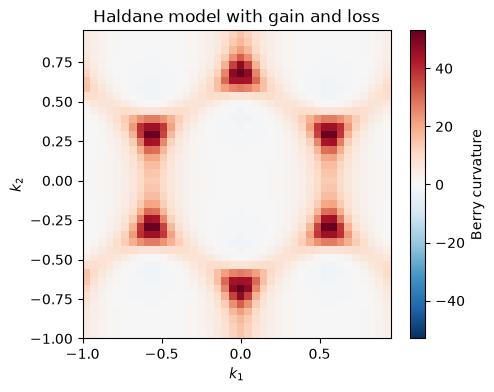

In [5]:
g = geometry.honeycomb_lattice() # honeycomb lattice
h = g.get_hamiltonian(has_spin=False,non_hermitian=True) # non-Hermitian Hamiltonian
h.add_haldane(0.1) # Haldane coupling, a Chern insulator
h.add_onsite(lambda r: 0.2j*np.sign(r[0])) # gain on one sublattice, loss on the other

nk = 40
(kx,ky,b) = h.get_berry_curvature(nk=nk,write=False) # Berry curvature on a k-mesh

plt.figure(figsize=(5,4))
bmax = np.max(np.abs(b.real))
plt.imshow(b.real.reshape(nk,nk).T,origin="lower",cmap="RdBu_r",vmin=-bmax,vmax=bmax,
        extent=[kx.min(),kx.max(),ky.min(),ky.max()])
plt.colorbar(label="Berry curvature")
plt.xlabel("$k_1$") ; plt.ylabel("$k_2$")
plt.title("Haldane model with gain and loss")
plt.show()